# Judge accuracy (Alt-Test)

Same scoring path as `uv run run_judges.py --accuracy-only`: each judge is scored against the three human ratings with the [Alternative Annotator Test](https://arxiv.org/abs/2501.10970).

Headline number is **average advantage probability ρ** (chance the judge is as good as or better than a randomly chosen annotator). Winning rate **ω** uses ε = 0.15 and is secondary. **llm** / **hum** are leave-one-out agreement with the other two labelers.

Unparsed judge replies are **not** treated as an Incorrect verdict. They enter the Alt-Test as a label that matches neither human pass nor fail, so they count as disagreements. **parse** is the share of stored answers with a `pass`/`fail` verdict.

ρ intervals are 95% question-clustered bootstrap CIs. Charts omit prompt modes with no verdicts.


In [1]:
%matplotlib inline
from __future__ import annotations

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from grader import JUDGE_FORMATS, grade_mode_title, parse_judge_key
from run_judges import LOCAL_PACK_DIR, report_judge_accuracy

plt.rcParams.update(
    {
        "figure.dpi": 130,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.axisbelow": True,
        "font.size": 11,
        "axes.titlesize": 13,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)

payload = report_judge_accuracy(LOCAL_PACK_DIR)
print(
    f"\npack={payload['pack']}  rows={payload['n_label_rows']}  "
    f"questions={payload['n_questions']}  ε={payload['epsilon']}"
)


=== judge Alt-Test (with_gt (text, sees gold), ε=0.150) ===
llm = judge agreement with the other two labelers (leave-one-out ACC)
hum = excluded labeler's agreement with those same two
parse = share of stored judge answers with a pass/fail verdict
judge                                                     n   miss    unp    parse     <3        ρ      llm      hum        ω  pass
af-next-think__with_gt__gold                           3834      0     81    0.982    729    0.816    0.737    0.889    0.000    no
gemma-4-12b__with_gt__gold                             3834      0      0    1.000    729    0.955    0.879    0.889    1.000   yes
gemma-4-e4b__with_gt__gold                             3834      0     10    0.998    729    0.935    0.860    0.889    1.000   yes
nemotron-3-nano-omni__with_gt__gold                    3834      0      0    1.000    729    0.951    0.876    0.889    1.000   yes
phi-4-multimodal__with_gt__gold                        3834      0      0    1.000    729  

In [2]:
MODE_ORDER = [m for m in (payload.get("modes") or []) if payload.get(m)]
MODE_COLORS = {
    "with_gt": "#4C78A8",
    "free": "#F58518",
    "neutral_with_gt": "#54A24B",
    "neutral_with_gt_no_audio": "#72B7B2",
    "neutral_no_gt": "#E45756",
}


def flatten_accuracy(payload: dict) -> pd.DataFrame:
    rows = []
    for mode in payload.get("modes") or []:
        by_judge = payload.get(mode) or {}
        if not isinstance(by_judge, dict) or not by_judge:
            continue
        fmt = JUDGE_FORMATS.get(mode)
        for key, stats in sorted(by_judge.items()):
            parsed = parse_judge_key(key)
            rows.append(
                {
                    "key": key,
                    "model": parsed.get("model") or key,
                    "mode": mode,
                    "mode_title": grade_mode_title(mode),
                    "sees_gold": None if fmt is None else bool(fmt.include_gold),
                    "hears_audio": None if fmt is None else bool(fmt.audio_included),
                    "n": stats.get("n"),
                    "n_missing": stats.get("n_missing"),
                    "n_unparsed": stats.get("n_unparsed"),
                    "parse_rate": stats.get("parse_rate"),
                    "n_skipped_lt3": stats.get("n_skipped_lt3"),
                    "rho": stats.get("advantage_prob"),
                    "rho_lo": stats.get("advantage_prob_ci_low"),
                    "rho_hi": stats.get("advantage_prob_ci_high"),
                    "llm": stats.get("loo_agree_judge"),
                    "hum": stats.get("loo_agree_human"),
                    "omega": stats.get("winning_rate"),
                    "passed": stats.get("passed"),
                }
            )
    return pd.DataFrame(rows)


df = flatten_accuracy(payload)
if df.empty:
    raise SystemExit(f"No scored judges in {LOCAL_PACK_DIR}")

model_order = (
    df.loc[df["mode"] == MODE_ORDER[0]]
    .sort_values("rho", ascending=False)["model"]
    .tolist()
)
for model in df["model"]:
    if model not in model_order:
        model_order.append(model)
df["model"] = pd.Categorical(df["model"], categories=model_order, ordered=True)
df["mode"] = pd.Categorical(df["mode"], categories=MODE_ORDER, ordered=True)
df = df.sort_values(["mode", "model"]).reset_index(drop=True)


def mode_label(mode: str) -> str:
    return grade_mode_title(mode).replace(" (", "\n(", 1)


def pivot(metric: str) -> pd.DataFrame:
    return (
        df.pivot_table(index="model", columns="mode", values=metric, observed=True)
        .reindex(index=model_order, columns=MODE_ORDER)
    )


summary = (
    df.groupby("mode", observed=True)
    .agg(
        n_judges=("key", "size"),
        n_pass=("passed", lambda s: int(s.fillna(False).astype(bool).sum())),
        mean_rho=("rho", "mean"),
        mean_llm=("llm", "mean"),
        mean_hum=("hum", "mean"),
        mean_parse=("parse_rate", "mean"),
    )
    .reindex(MODE_ORDER)
)
print("By prompt mode")
display(summary.round(3))
print("Per judge (same columns as --accuracy-only)")
display(
    df[
        [
            "mode",
            "model",
            "n",
            "n_missing",
            "n_unparsed",
            "parse_rate",
            "n_skipped_lt3",
            "rho",
            "rho_lo",
            "rho_hi",
            "llm",
            "hum",
            "omega",
            "passed",
        ]
    ].style.format(
        {
            "parse_rate": "{:.3f}",
            "rho": "{:.3f}",
            "rho_lo": "{:.3f}",
            "rho_hi": "{:.3f}",
            "llm": "{:.3f}",
            "hum": "{:.3f}",
            "omega": "{:.3f}",
        },
        na_rep="—",
    )
)

By prompt mode


,n_judges,n_pass,mean_rho,mean_llm,mean_hum,mean_parse
mode,,,,,,
with_gt,9,7,0.919,0.843,0.889,0.997
free,8,0,0.632,0.551,0.889,0.962
neutral_with_gt,8,6,0.880,0.806,0.889,0.944
neutral_with_gt_no_audio,8,7,0.913,0.839,0.889,0.981
neutral_no_gt,8,0,0.582,0.501,0.889,0.912


Per judge (same columns as --accuracy-only)


,mode,model,n,n_missing,n_unparsed,parse_rate,n_skipped_lt3,rho,rho_lo,rho_hi,llm,hum,omega,passed
0,with_gt,qwen3.6-35b-a3b-fp8,3834,0,0,1.000,729,0.961,0.946,0.975,0.886,0.889,1.000,True
1,with_gt,gemma-4-12b,3834,0,0,1.000,729,0.955,0.939,0.969,0.879,0.889,1.000,True
2,with_gt,nemotron-3-nano-omni,3834,0,0,1.000,729,0.951,0.932,0.968,0.876,0.889,1.000,True
3,with_gt,qwen2.5-omni-7b,3834,0,0,1.000,729,0.942,0.926,0.957,0.866,0.889,1.000,True
4,with_gt,qwen3-omni,3834,0,18,0.996,729,0.940,0.919,0.959,0.865,0.889,1.000,True
5,with_gt,voxtral-small-24b,3834,0,26,0.994,729,0.939,0.921,0.956,0.864,0.889,1.000,True
6,with_gt,gemma-4-e4b,3834,0,10,0.998,729,0.935,0.914,0.954,0.860,0.889,1.000,True
7,with_gt,phi-4-multimodal,3834,0,0,1.000,729,0.832,0.805,0.857,0.753,0.889,0.333,False
8,with_gt,af-next-think,3834,0,81,0.982,729,0.816,0.796,0.834,0.737,0.889,0.000,False
9,free,gemma-4-12b,3834,0,31,0.993,729,0.569,0.525,0.610,0.486,0.889,0.000,False


## ρ by judge and prompt

Average advantage probability. Each cell is ρ and its 95% CI `[lo, hi]`. A `*` marks an Alt-Test pass (ω > 0.5 at ε = 0.15). Gold prompts sit near the human ceiling; no-gold prompts do not.


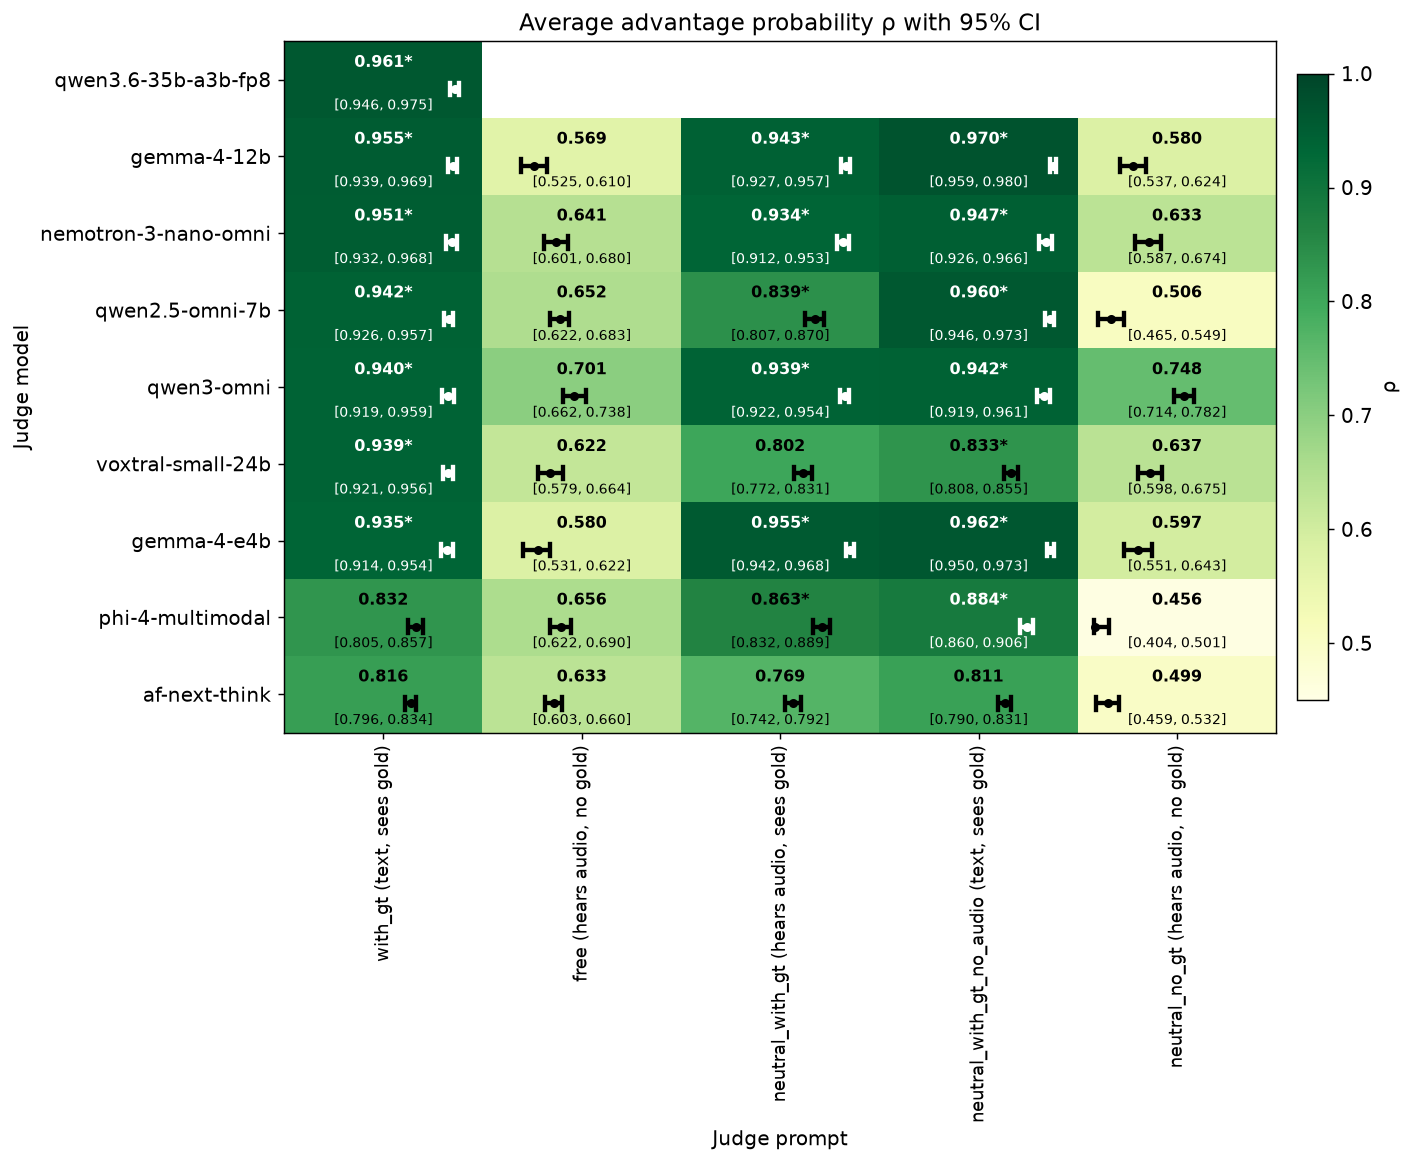

In [3]:
rho = pivot("rho")
rho_lo = pivot("rho_lo")
rho_hi = pivot("rho_hi")
passed = pivot("passed")

fig, ax = plt.subplots(figsize=(10, 0.55 * len(model_order) + 2.4))
data = rho.to_numpy(dtype=float)
lo_g = rho_lo.to_numpy(dtype=float)
hi_g = rho_hi.to_numpy(dtype=float)
masked = np.ma.masked_invalid(data)
im = ax.imshow(masked, aspect="auto", cmap="YlGn", vmin=0.45, vmax=1.0)
ax.set_xticks(np.arange(len(MODE_ORDER)))
ax.set_xticklabels(
    [grade_mode_title(m) for m in MODE_ORDER],
    rotation=90,
    ha="center",
    va="top",
    fontsize=10,
)
ax.set_yticks(np.arange(len(model_order)))
ax.set_yticklabels(model_order)
ax.set_title("Average advantage probability ρ (95% CI)")
ax.set_xlabel("Judge prompt")
ax.set_ylabel("Judge model")
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        value = data[i, j]
        if np.isnan(value):
            continue
        star = "*" if passed.iloc[i, j] is True else ""
        ink = "white" if value >= 0.88 else "black"
        ax.text(
            j,
            i - 0.16,
            f"{value:.3f}{star}",
            ha="center",
            va="center",
            color=ink,
            fontsize=9,
        )
        lo, hi = lo_g[i, j], hi_g[i, j]
        if np.isfinite(lo) and np.isfinite(hi):
            ax.text(
                j,
                i + 0.20,
                f"[{lo:.3f}, {hi:.3f}]",
                ha="center",
                va="center",
                color=ink,
                fontsize=8,
            )

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("ρ")
fig.tight_layout()
plt.show()


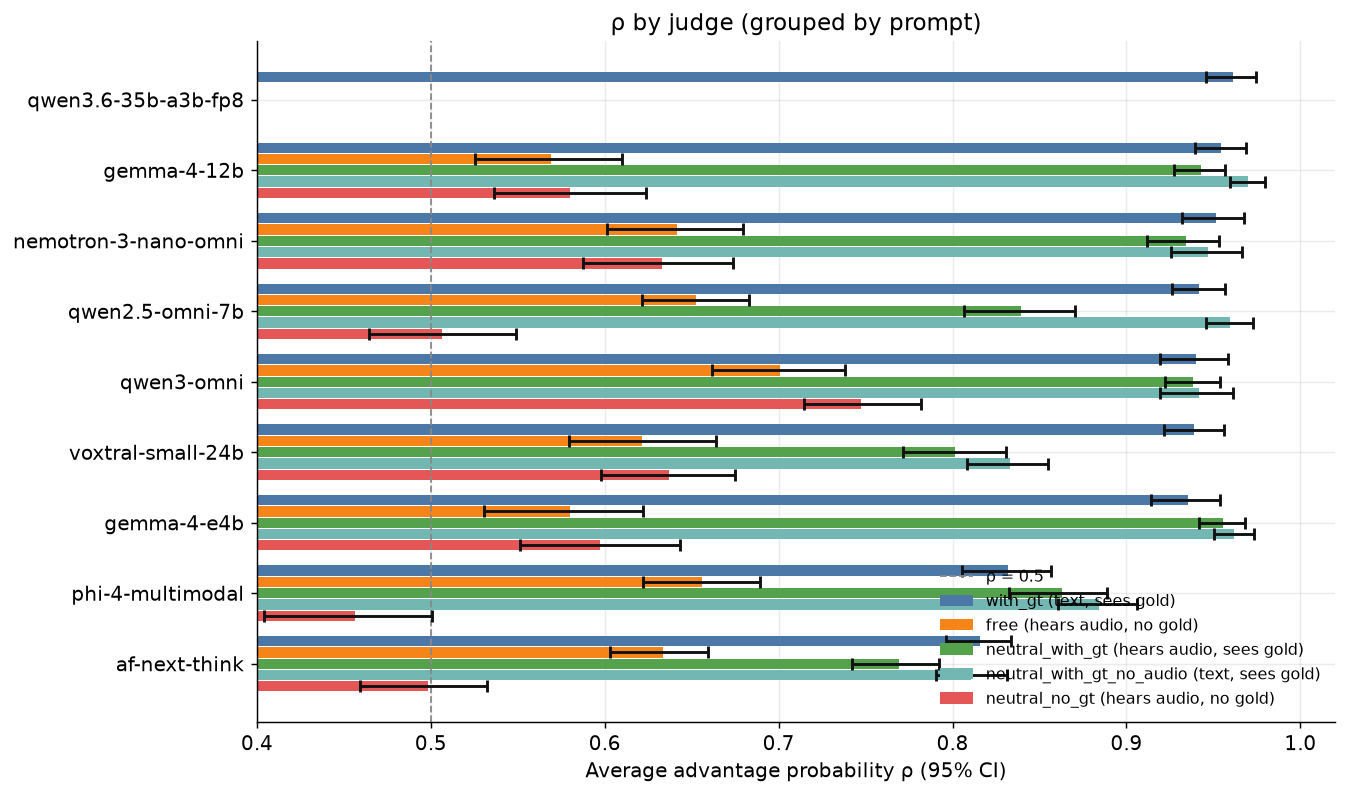

In [4]:
fig, ax = plt.subplots(figsize=(10, 0.38 * len(model_order) + 1.8))
n_modes = len(MODE_ORDER)
width = 0.8 / n_modes
y = np.arange(len(model_order))
for i, mode in enumerate(MODE_ORDER):
    sub = df[df["mode"] == mode].set_index("model").reindex(model_order)
    x = sub["rho"].to_numpy(dtype=float)
    ypos = y + (i - (n_modes - 1) / 2) * width
    ok = np.isfinite(x)
    ax.barh(
        ypos[ok],
        x[ok],
        height=width * 0.92,
        color=MODE_COLORS.get(mode, "#4C78A8"),
        label=grade_mode_title(mode),
    )
ax.set_yticks(y)
ax.set_yticklabels(model_order)
ax.set_xlabel("Average advantage probability ρ")
ax.set_xlim(0.45, 1.0)
ax.axvline(0.5, color="#888888", linewidth=1, linestyle="--", label="ρ = 0.5")
ax.set_title("ρ by judge (grouped by prompt)")
ax.legend(loc="lower right", fontsize=9, frameon=False)
ax.invert_yaxis()
fig.tight_layout()
plt.show()


## Parse rate

Share of stored judge answers with a `pass`/`fail` verdict. Unparsed text is scored as a disagreement in ρ above (it never matches a human label), not as Incorrect.


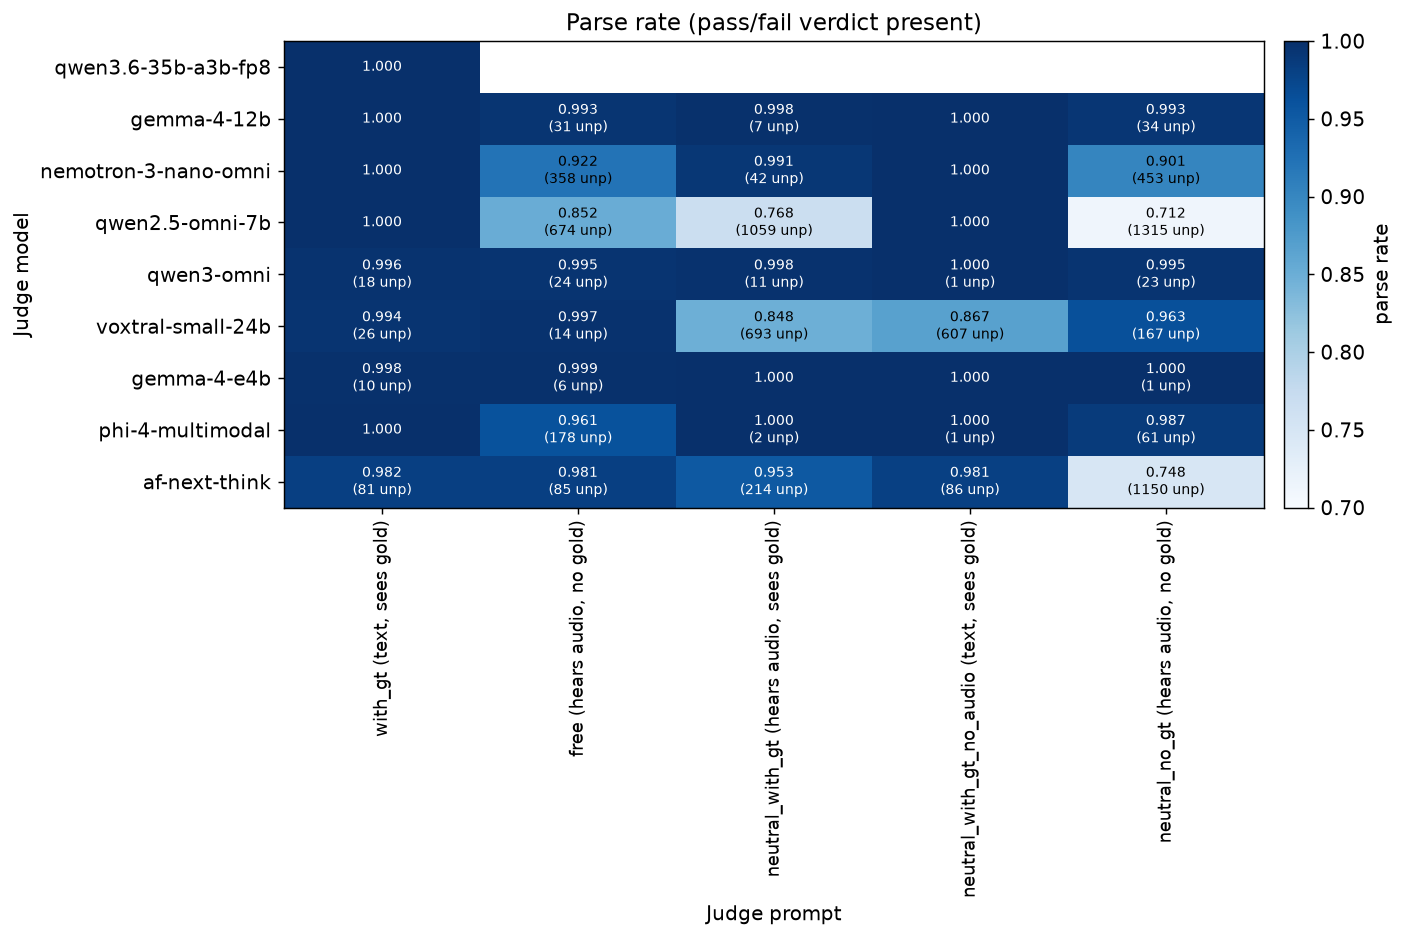

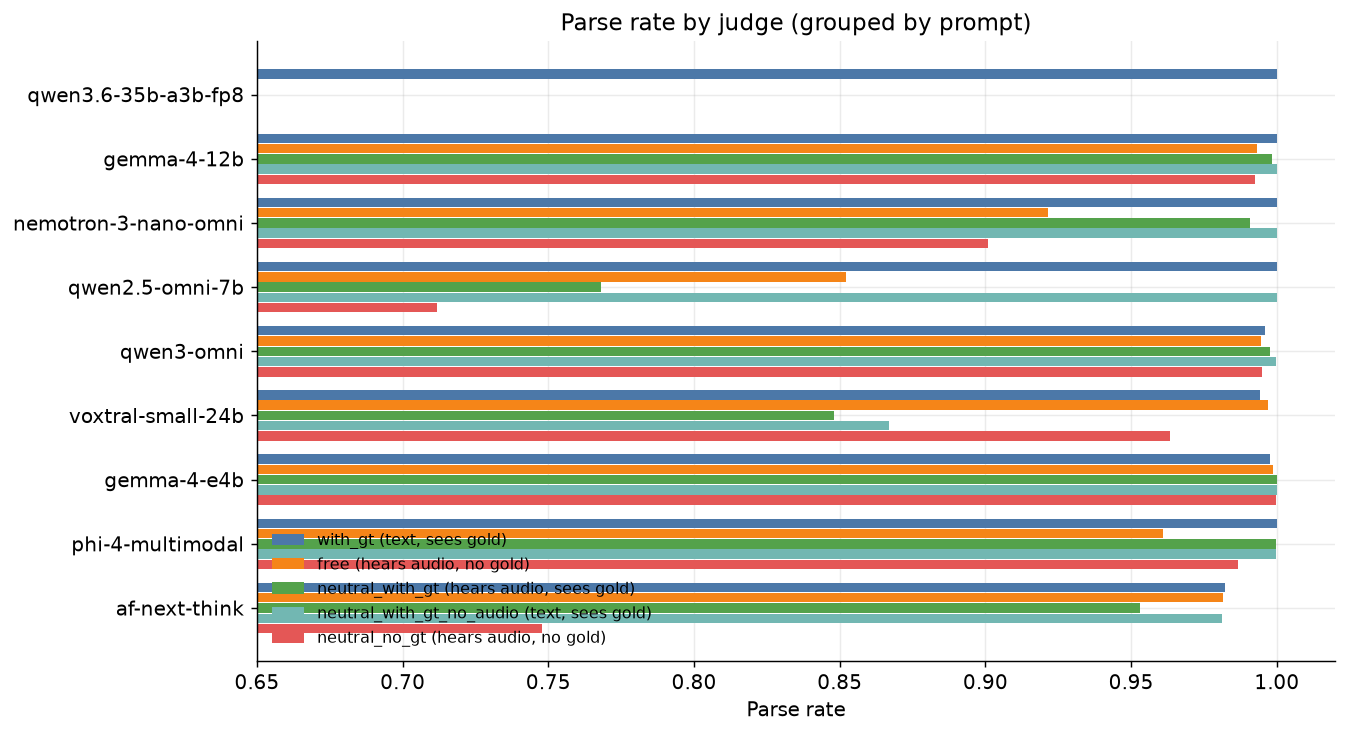

In [5]:
parse = pivot("parse_rate")
unparsed = pivot("n_unparsed")

fig, ax = plt.subplots(figsize=(11, 0.55 * len(model_order) + 2.4))
data = parse.to_numpy(dtype=float)
unp_g = unparsed.to_numpy(dtype=float)
masked = np.ma.masked_invalid(data)
im = ax.imshow(masked, aspect="auto", cmap="Blues", vmin=0.7, vmax=1.0)
ax.set_xticks(np.arange(len(MODE_ORDER)))
ax.set_xticklabels(
    [grade_mode_title(m) for m in MODE_ORDER],
    rotation=90,
    ha="center",
    va="top",
    fontsize=10,
)
ax.set_yticks(np.arange(len(model_order)))
ax.set_yticklabels(model_order)
ax.set_title("Parse rate (pass/fail verdict present)")
ax.set_xlabel("Judge prompt")
ax.set_ylabel("Judge model")
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        value = data[i, j]
        if np.isnan(value):
            continue
        n_unp = unp_g[i, j]
        extra = f"\n({int(n_unp)} unp)" if np.isfinite(n_unp) and n_unp else ""
        ax.text(
            j,
            i,
            f"{value:.3f}{extra}",
            ha="center",
            va="center",
            color="white" if value >= 0.93 else "black",
            fontsize=8,
        )

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("parse rate")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10.5, 0.42 * len(model_order) + 2.0))
n_modes = len(MODE_ORDER)
width = 0.8 / n_modes
y = np.arange(len(model_order))
for i, mode in enumerate(MODE_ORDER):
    sub = df[df["mode"] == mode].set_index("model").reindex(model_order)
    x = sub["parse_rate"].to_numpy(dtype=float)
    ypos = y + (i - (n_modes - 1) / 2) * width
    ok = np.isfinite(x)
    ax.barh(
        ypos[ok],
        x[ok],
        height=width * 0.92,
        color=MODE_COLORS.get(mode, "#4C78A8"),
        label=grade_mode_title(mode),
    )
ax.set_yticks(y)
ax.set_yticklabels(model_order)
ax.set_xlabel("Parse rate")
ax.set_xlim(0.65, 1.02)
ax.set_title("Parse rate by judge (grouped by prompt)")
ax.legend(loc="lower left", fontsize=9, frameon=False)
ax.invert_yaxis()
fig.tight_layout()
plt.show()


## Leave-one-out agreement

**llm** is the judge vs the other two humans; **hum** is the held-out human vs those same two (the annotator ceiling). Gold prompts close most of the gap; `free` does not.


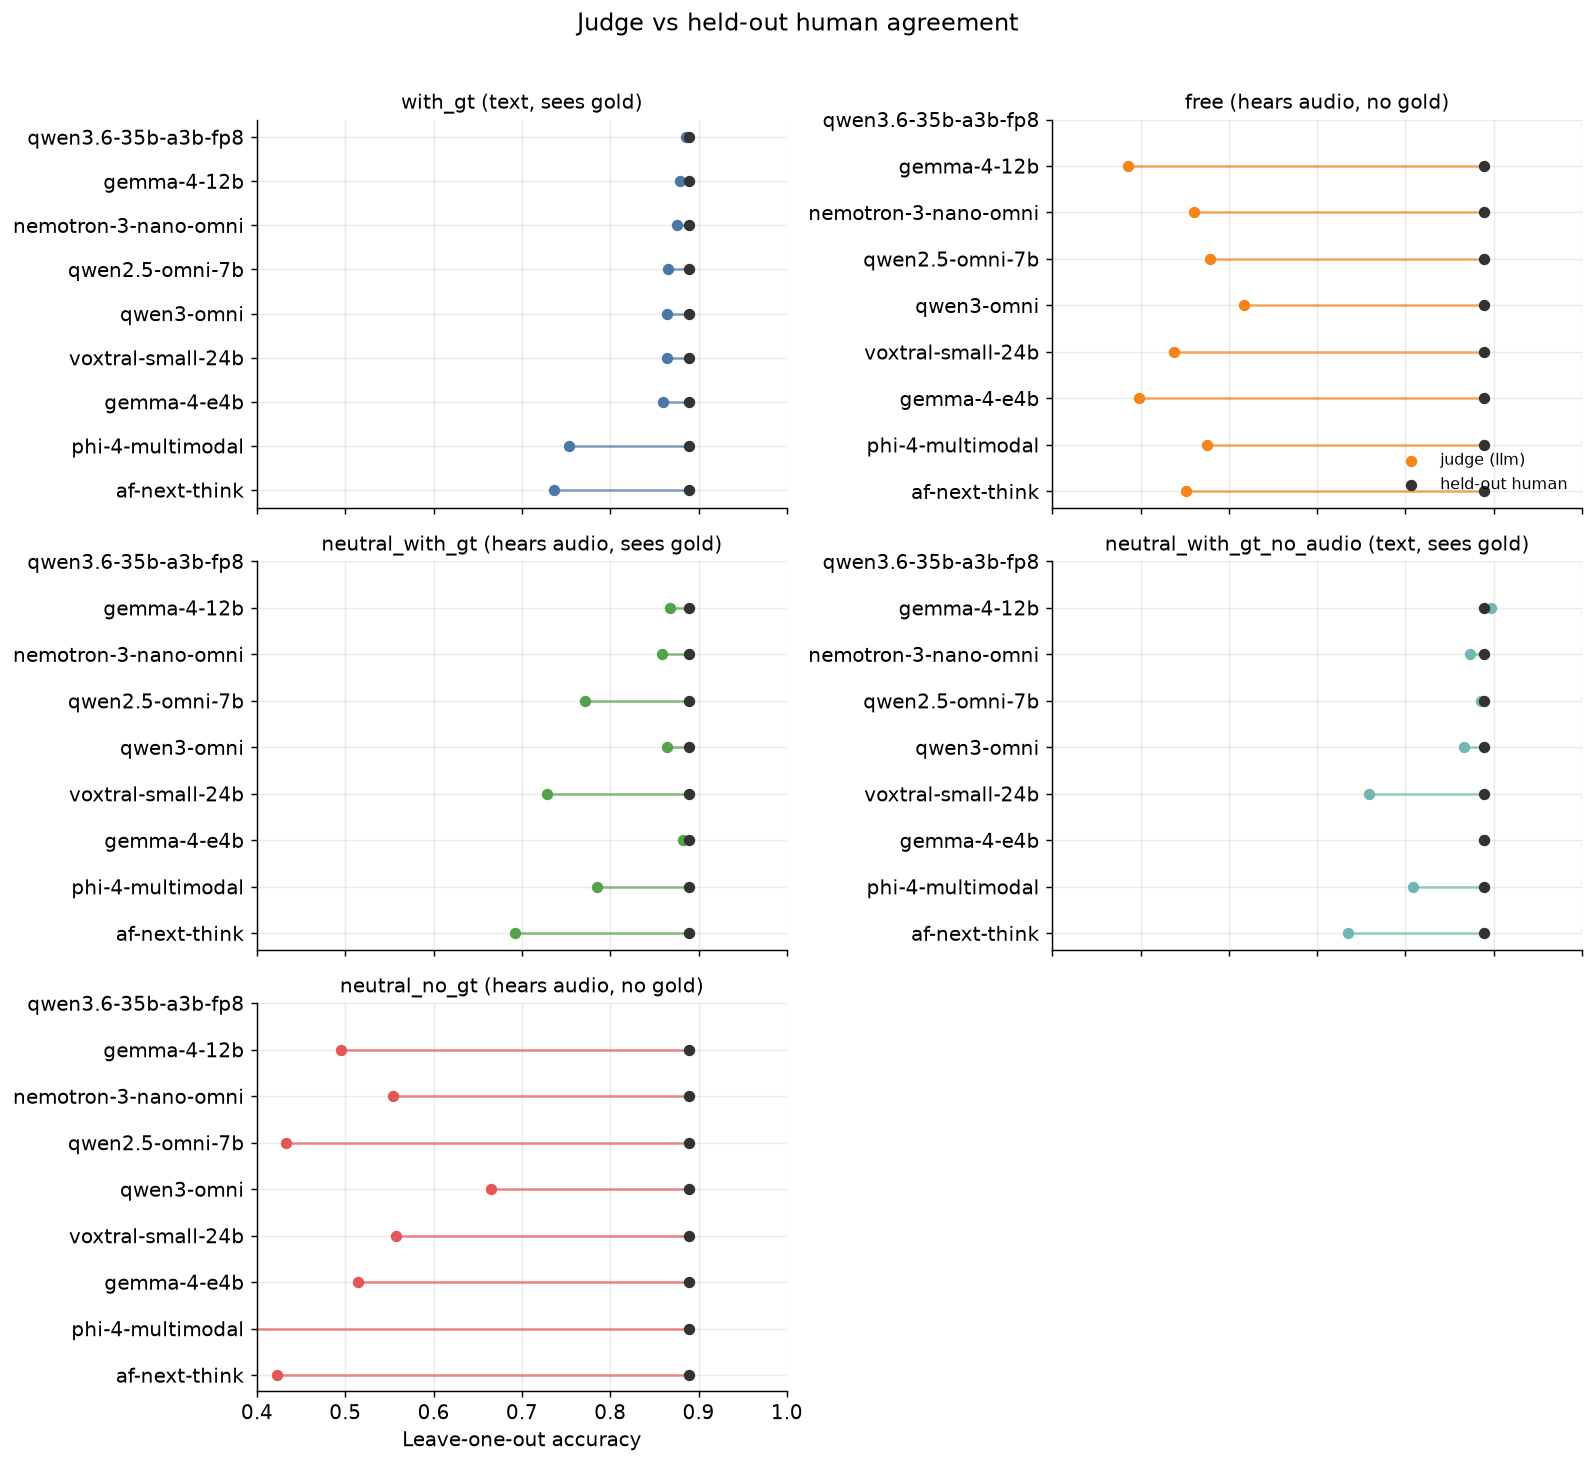

In [6]:
n_modes = len(MODE_ORDER)
ncols = 2 if n_modes > 1 else 1
nrows = int(np.ceil(n_modes / ncols))
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(6.2 * ncols, 0.36 * len(model_order) * nrows + 1.4),
    sharex=True,
)
axes = np.atleast_1d(axes).ravel()

for ax, mode in zip(axes, MODE_ORDER):
    sub = df[df["mode"] == mode].set_index("model").reindex(model_order)
    y = np.arange(len(model_order))
    llm = sub["llm"].to_numpy(dtype=float)
    hum = sub["hum"].to_numpy(dtype=float)
    color = MODE_COLORS.get(mode, "#4C78A8")
    for yi, a, b in zip(y, llm, hum):
        if np.isnan(a) or np.isnan(b):
            continue
        ax.plot([a, b], [yi, yi], color=color, linewidth=1.4, alpha=0.7)
    ax.scatter(llm, y, color=color, s=28, zorder=3, label="judge (llm)")
    ax.scatter(hum, y, color="#333333", s=28, zorder=3, label="held-out human")
    ax.set_yticks(y)
    ax.set_yticklabels(model_order)
    ax.set_title(grade_mode_title(mode), fontsize=11)
    ax.set_xlim(0.4, 1.0)
    ax.invert_yaxis()

for ax in axes[n_modes:]:
    ax.set_visible(False)

axes[min(1, n_modes - 1)].legend(loc="lower right", fontsize=9, frameon=False)
for ax in axes[(nrows - 1) * ncols :]:
    if ax.get_visible():
        ax.set_xlabel("Leave-one-out accuracy")
fig.suptitle("Judge vs held-out human agreement", y=1.01)
fig.tight_layout()
plt.show()

## Gold vs no-gold, and audio vs text with gold

Left: ρ drop when the gold answer is removed (`with_gt` → `free`). Right: ρ change when audio is removed from a gold-supplied neutral prompt. The audio ablation should be small if the reference, not the clip, is doing the work.


,ρ left,ρ right,Δρ
model,,,
gemma-4-12b,0.955,0.569,0.385
nemotron-3-nano-omni,0.951,0.641,0.310
qwen2.5-omni-7b,0.942,0.652,0.289
qwen3-omni,0.940,0.701,0.239
voxtral-small-24b,0.939,0.622,0.317
gemma-4-e4b,0.935,0.580,0.355
phi-4-multimodal,0.832,0.656,0.176
af-next-think,0.816,0.633,0.182


,ρ left,ρ right,Δρ
model,,,
gemma-4-12b,0.943,0.970,-0.027
nemotron-3-nano-omni,0.934,0.947,-0.013
qwen2.5-omni-7b,0.839,0.960,-0.121
qwen3-omni,0.939,0.942,-0.003
voxtral-small-24b,0.802,0.833,-0.031
gemma-4-e4b,0.955,0.962,-0.007
phi-4-multimodal,0.863,0.884,-0.021
af-next-think,0.769,0.811,-0.042


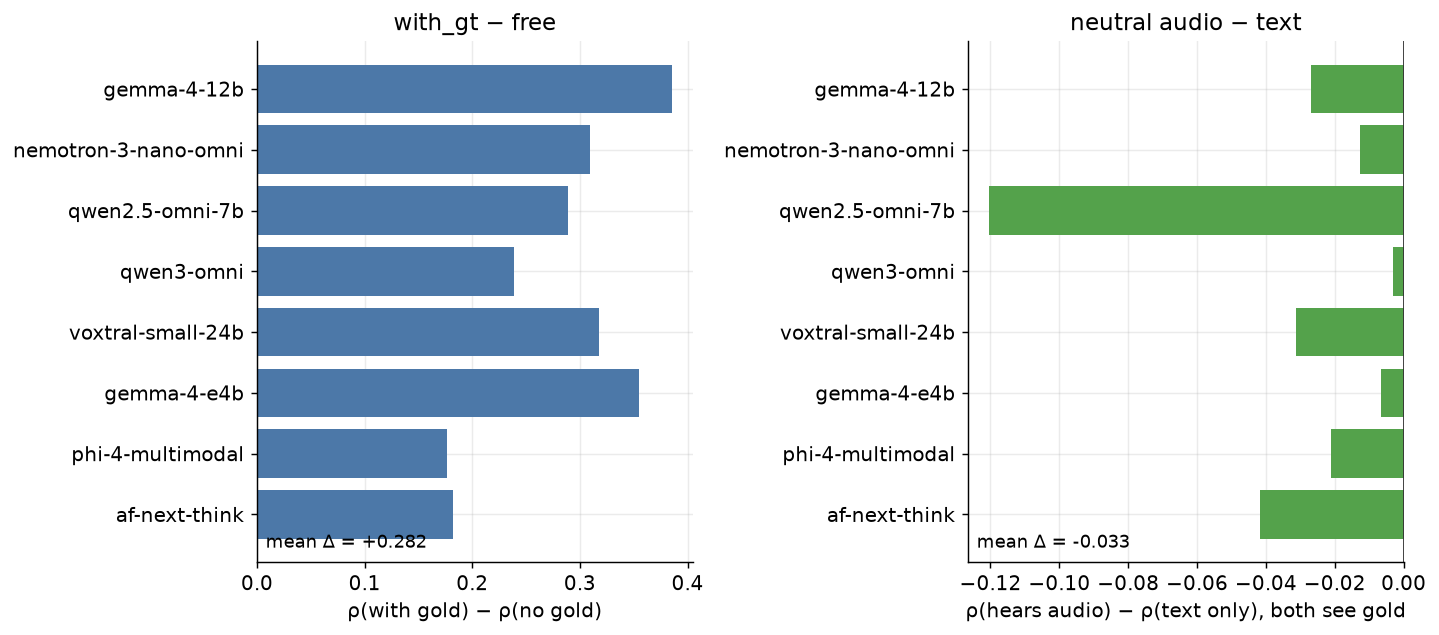

In [7]:
def paired_delta(left: str, right: str) -> pd.DataFrame:
    a = df[df["mode"] == left].set_index("model")["rho"]
    b = df[df["mode"] == right].set_index("model")["rho"]
    both = a.index.intersection(b.index)
    out = pd.DataFrame({"left": a.loc[both], "right": b.loc[both]})
    out["delta"] = out["left"] - out["right"]
    return out.reindex([m for m in model_order if m in out.index])


pairs = []
if "with_gt" in MODE_ORDER and "free" in MODE_ORDER:
    pairs.append(
        (
            "with_gt − free",
            "ρ(with gold) − ρ(no gold)",
            paired_delta("with_gt", "free"),
            "#4C78A8",
        )
    )
if "neutral_with_gt" in MODE_ORDER and "neutral_with_gt_no_audio" in MODE_ORDER:
    pairs.append(
        (
            "neutral audio − text",
            "ρ(hears audio) − ρ(text only), both see gold",
            paired_delta("neutral_with_gt", "neutral_with_gt_no_audio"),
            "#54A24B",
        )
    )

if not pairs:
    print("No paired modes to compare.")
else:
    fig, axes = plt.subplots(1, len(pairs), figsize=(5.6 * len(pairs), 0.38 * len(model_order) + 1.6))
    axes = np.atleast_1d(axes)
    for ax, (title, xlabel, table, color) in zip(axes, pairs):
        y = np.arange(len(table))
        ax.barh(y, table["delta"].to_numpy(dtype=float), color=color)
        ax.axvline(0, color="#333333", linewidth=1)
        ax.set_yticks(y)
        ax.set_yticklabels(table.index)
        ax.set_xlabel(xlabel)
        ax.set_title(title)
        ax.invert_yaxis()
        mean = float(table["delta"].mean())
        ax.text(
            0.02,
            0.02,
            f"mean Δ = {mean:+.3f}",
            transform=ax.transAxes,
            fontsize=10,
            va="bottom",
        )
        display(table.rename(columns={"left": "ρ left", "right": "ρ right", "delta": "Δρ"}).round(3))
    fig.tight_layout()
    plt.show()